# EPC Estimator for Flats

This notebook estimates the Energy Performance Certificate (EPC) rating for domestic flats in the UK.

EPC ratings range from A (most efficient) to G (least efficient), based on the property's energy efficiency and environmental impact.

## Key Factors for Flats

- **Building fabric**: Walls, roof, floors, windows
- **Heating system**: Type, efficiency, controls
- **Hot water**: System type and efficiency
- **Lighting**: Low-energy lighting percentage
- **Ventilation**: Natural vs mechanical
- **Property position**: Ground floor, mid-floor, top floor

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple
from enum import Enum

# Set up plotting style
plt.style.use('default')
%matplotlib inline

## 1. Define Data Classes and Enums

In [2]:
class FlatPosition(Enum):
    """Position of flat within building"""
    GROUND_FLOOR = "ground_floor"
    MID_FLOOR = "mid_floor"
    TOP_FLOOR = "top_floor"
    SINGLE_STOREY = "single_storey"

class WallType(Enum):
    """Wall construction type"""
    SOLID_UNINSULATED = "solid_uninsulated"
    SOLID_INSULATED = "solid_insulated"
    CAVITY_UNINSULATED = "cavity_uninsulated"
    CAVITY_INSULATED = "cavity_insulated"
    TIMBER_FRAME = "timber_frame"

class HeatingType(Enum):
    """Primary heating system"""
    GAS_BOILER_OLD = "gas_boiler_old"
    GAS_BOILER_MODERATE = "gas_boiler_moderate"
    GAS_BOILER_EFFICIENT = "gas_boiler_efficient"
    ELECTRIC_STORAGE = "electric_storage"
    ELECTRIC_DIRECT = "electric_direct"
    HEAT_PUMP = "heat_pump"
    DISTRICT_HEATING = "district_heating"
    COMMUNITY_HEATING = "community_heating"

class WindowType(Enum):
    """Window glazing type"""
    SINGLE_GLazed = "single_glazed"
    DOUBLE_GLazed_OLD = "double_glazed_old"
    DOUBLE_GLazed_NEW = "double_glazed_new"
    TRIPLE_GLazed = "triple_glazed"

class HotWaterType(Enum):
    """Hot water system"""
    FROM_HEATING = "from_heating"
    ELECTRIC_IMMERSION = "electric_immersion"
    GAS_INSTANT = "gas_instant"
    SOLAR_THERMAL = "solar_thermal"

@dataclass
class FlatProperties:
    """Physical properties of the flat"""
    floor_area_sqm: float
    position: FlatPosition
    num_bedrooms: int
    num_occupants: int
    year_built: int
    wall_type: WallType
    window_type: WindowType
    heating_type: HeatingType
    hot_water_type: HotWaterType
    has_cylinder_thermostat: bool = False
    has_room_thermostat: bool = False
    has_trvs: bool = False
    low_energy_lighting_pct: float = 0.0
    has_solar_pv: bool = False
    solar_pv_kw: float = 0.0
    flat_below_insulated: bool = True
    flat_above_insulated: bool = True

## 2. EPC Calculation Engine

In [3]:
class EPCEstimator:
    WALL_U_VALUES = {
        WallType.SOLID_UNINSULATED: 2.1,
        WallType.SOLID_INSULATED: 0.6,
        WallType.CAVITY_UNINSULATED: 1.5,
        WallType.CAVITY_INSULATED: 0.5,
        WallType.TIMBER_FRAME: 0.4,
    }
    
    WINDOW_U_VALUES = {
        WindowType.SINGLE_GLazed: 4.8,
        WindowType.DOUBLE_GLazed_OLD: 3.1,
        WindowType.DOUBLE_GLazed_NEW: 1.8,
        WindowType.TRIPLE_GLazed: 1.0,
    }
    
    HEATING_EFFICIENCIES = {
        HeatingType.GAS_BOILER_OLD: 0.65,
        HeatingType.GAS_BOILER_MODERATE: 0.78,
        HeatingType.GAS_BOILER_EFFICIENT: 0.90,
        HeatingType.ELECTRIC_STORAGE: 1.0,
        HeatingType.ELECTRIC_DIRECT: 1.0,
        HeatingType.HEAT_PUMP: 3.0,
        HeatingType.DISTRICT_HEATING: 0.85,
        HeatingType.COMMUNITY_HEATING: 0.80,
    }
    
    FUEL_COSTS = {
        HeatingType.GAS_BOILER_OLD: 7.0,
        HeatingType.GAS_BOILER_MODERATE: 7.0,
        HeatingType.GAS_BOILER_EFFICIENT: 7.0,
        HeatingType.ELECTRIC_STORAGE: 30.0,
        HeatingType.ELECTRIC_DIRECT: 30.0,
        HeatingType.HEAT_PUMP: 10.0,
        HeatingType.DISTRICT_HEATING: 8.0,
        HeatingType.COMMUNITY_HEATING: 8.0,
    }
    
    CO2_FACTORS = {
        HeatingType.GAS_BOILER_OLD: 0.210,
        HeatingType.GAS_BOILER_MODERATE: 0.210,
        HeatingType.GAS_BOILER_EFFICIENT: 0.210,
        HeatingType.ELECTRIC_STORAGE: 0.136,
        HeatingType.ELECTRIC_DIRECT: 0.136,
        HeatingType.HEAT_PUMP: 0.045,
        HeatingType.DISTRICT_HEATING: 0.150,
        HeatingType.COMMUNITY_HEATING: 0.180,
    }
    
    def __init__(self, flat: FlatProperties):
        self.flat = flat
    
    def calculate_heat_loss(self) -> dict:
        area = self.flat.floor_area_sqm
        height = 2.5
        width = np.sqrt(area)
        depth = area / width
        external_wall_area = (width + depth) * height
        window_area = area * 0.18
        
        if self.flat.position == FlatPosition.GROUND_FLOOR:
            floor_area = area
            ceiling_area = area if not self.flat.flat_above_insulated else 0
        elif self.flat.position == FlatPosition.TOP_FLOOR:
            floor_area = 0 if self.flat.flat_below_insulated else area
            ceiling_area = area
        elif self.flat.position == FlatPosition.MID_FLOOR:
            floor_area = 0 if self.flat.flat_below_insulated else area
            ceiling_area = 0 if self.flat.flat_above_insulated else area
        else:
            floor_area = area
            ceiling_area = area
        
        wall_u = self.WALL_U_VALUES[self.flat.wall_type]
        window_u = self.WINDOW_U_VALUES[self.flat.window_type]
        floor_u = 0.7
        ceiling_u = 0.25
        temp_diff = 20
        
        wall_loss = external_wall_area * wall_u * temp_diff
        window_loss = window_area * window_u * temp_diff
        floor_loss = floor_area * floor_u * temp_diff
        ceiling_loss = ceiling_area * ceiling_u * temp_diff
        
        air_changes = 0.5
        air_density = 1.2
        specific_heat = 1005
        volume = area * height
        vent_loss = (volume * air_changes * air_density * specific_heat * temp_diff) / 3600
        
        total_loss = wall_loss + window_loss + floor_loss + ceiling_loss + vent_loss
        
        return {
            'wall_loss_w': wall_loss,
            'window_loss_w': window_loss,
            'floor_loss_w': floor_loss,
            'ceiling_loss_w': ceiling_loss,
            'ventilation_loss_w': vent_loss,
            'total_loss_w': total_loss,
        }
    
    def calculate_annual_energy(self) -> dict:
        heat_loss = self.calculate_heat_loss()
        heating_hours = 200 * 24 * 0.6
        space_heating_kwh = (heat_loss['total_loss_w'] * heating_hours) / 1000
        
        control_factor = 1.0
        if self.flat.has_room_thermostat:
            control_factor -= 0.10
        if self.flat.has_trvs:
            control_factor -= 0.05
        if self.flat.has_cylinder_thermostat:
            control_factor -= 0.05
        
        space_heating_kwh *= max(0.7, control_factor)
        hot_water_kwh = self.flat.floor_area_sqm * 50
        lighting_kwh = self.flat.floor_area_sqm * 10
        lighting_kwh *= (1 - (self.flat.low_energy_lighting_pct / 100) * 0.75)
        appliance_kwh = 500 + (self.flat.num_occupants * 300)
        cooking_kwh = 200 + (self.flat.num_occupants * 100)
        
        solar_generation = 0
        if self.flat.has_solar_pv:
            solar_generation = self.flat.solar_pv_kw * 850
        
        total_consumption = space_heating_kwh + hot_water_kwh + lighting_kwh + appliance_kwh + cooking_kwh
        net_consumption = total_consumption - solar_generation
        
        return {
            'space_heating_kwh': space_heating_kwh,
            'hot_water_kwh': hot_water_kwh,
            'lighting_kwh': lighting_kwh,
            'appliance_kwh': appliance_kwh,
            'cooking_kwh': cooking_kwh,
            'solar_generation_kwh': solar_generation,
            'total_consumption_kwh': total_consumption,
            'net_consumption_kwh': net_consumption,
        }
    
    def calculate_epc(self) -> dict:
        energy = self.calculate_annual_energy()
        heating_eff = self.HEATING_EFFICIENCIES[self.flat.heating_type]
        fuel_cost_rate = self.FUEL_COSTS[self.flat.heating_type]
        co2_factor = self.CO2_FACTORS[self.flat.heating_type]
        
        space_heating_delivered = energy['space_heating_kwh'] / heating_eff
        
        if self.flat.hot_water_type == HotWaterType.FROM_HEATING:
            hot_water_delivered = energy['hot_water_kwh'] / heating_eff
        elif self.flat.hot_water_type in [HotWaterType.ELECTRIC_IMMERSION]:
            hot_water_delivered = energy['hot_water_kwh']
        else:
            hot_water_delivered = energy['hot_water_kwh'] / 0.8
        
        total_delivered = space_heating_delivered + hot_water_delivered + energy['lighting_kwh'] + energy['appliance_kwh'] + energy['cooking_kwh']
        primary_energy_per_sqm = total_delivered / self.flat.floor_area_sqm
        
        space_heating_co2 = space_heating_delivered * co2_factor
        hot_water_co2 = hot_water_delivered * co2_factor
        other_co2 = (energy['lighting_kwh'] + energy['appliance_kwh'] + energy['cooking_kwh']) * 0.136
        total_co2 = space_heating_co2 + hot_water_co2 + other_co2
        co2_per_sqm = total_co2 / self.flat.floor_area_sqm
        
        heating_cost = (space_heating_delivered + hot_water_delivered) * fuel_cost_rate / 100
        other_cost = (energy['lighting_kwh'] + energy['appliance_kwh'] + energy['cooking_kwh']) * 30 / 100
        total_cost = heating_cost + other_cost
        
        if co2_per_sqm <= 5:
            rating_band = 'A'
            rating_score = 92 + min(8, (5 - co2_per_sqm) * 2)
        elif co2_per_sqm <= 15:
            rating_band = 'B'
            rating_score = 81 + min(11, (15 - co2_per_sqm) * 1.1)
        elif co2_per_sqm <= 30:
            rating_band = 'C'
            rating_score = 69 + min(12, (30 - co2_per_sqm) * 0.8)
        elif co2_per_sqm <= 50:
            rating_band = 'D'
            rating_score = 55 + min(14, (50 - co2_per_sqm) * 0.7)
        elif co2_per_sqm <= 70:
            rating_band = 'E'
            rating_score = 39 + min(16, (70 - co2_per_sqm) * 0.8)
        elif co2_per_sqm <= 90:
            rating_band = 'F'
            rating_score = 21 + min(18, (90 - co2_per_sqm) * 0.9)
        else:
            rating_band = 'G'
            rating_score = max(1, 21 - (co2_per_sqm - 90) * 0.5)
        
        rating_score = round(rating_score)
        
        return {
            'rating_band': rating_band,
            'rating_score': rating_score,
            'primary_energy_kwh_m2': round(primary_energy_per_sqm, 1),
            'co2_emissions_kg_m2': round(co2_per_sqm, 1),
            'total_co2_kg_year': round(total_co2, 0),
            'estimated_annual_cost_gbp': round(total_cost, 0),
            'energy_breakdown': energy,
            'space_heating_delivered_kwh': round(space_heating_delivered, 0),
            'hot_water_delivered_kwh': round(hot_water_delivered, 0),
        }

## 3. Example Usage

In [4]:
# Example 1: Modern efficient flat
modern_flat = FlatProperties(
    floor_area_sqm=65,
    position=FlatPosition.MID_FLOOR,
    num_bedrooms=2,
    num_occupants=2,
    year_built=2015,
    wall_type=WallType.CAVITY_INSULATED,
    window_type=WindowType.DOUBLE_GLazed_NEW,
    heating_type=HeatingType.GAS_BOILER_EFFICIENT,
    hot_water_type=HotWaterType.FROM_HEATING,
    has_cylinder_thermostat=True,
    has_room_thermostat=True,
    has_trvs=True,
    low_energy_lighting_pct=80,
    flat_below_insulated=True,
    flat_above_insulated=True,
)

estimator1 = EPCEstimator(modern_flat)
result1 = estimator1.calculate_epc()

print("=== Modern Efficient Flat ===")
print(f"EPC Rating: {result1['rating_band']} ({result1['rating_score']}/100)")
print(f"Primary Energy: {result1['primary_energy_kwh_m2']} kWh/m2/year")
print(f"CO2 Emissions: {result1['co2_emissions_kg_m2']} kg/m2/year")
print(f"Est. Annual Cost: £{result1['estimated_annual_cost_gbp']}")

=== Modern Efficient Flat ===
EPC Rating: C (72/100)
Primary Energy: 136.5 kWh/m2/year
CO2 Emissions: 26.7 kg/m2/year
Est. Annual Cost: £1026.0


In [5]:
# Example 2: Older inefficient flat
old_flat = FlatProperties(
    floor_area_sqm=55,
    position=FlatPosition.TOP_FLOOR,
    num_bedrooms=1,
    num_occupants=1,
    year_built=1965,
    wall_type=WallType.SOLID_UNINSULATED,
    window_type=WindowType.SINGLE_GLazed,
    heating_type=HeatingType.ELECTRIC_DIRECT,
    hot_water_type=HotWaterType.ELECTRIC_IMMERSION,
    low_energy_lighting_pct=10,
    flat_below_insulated=False,
    flat_above_insulated=False,
)

estimator2 = EPCEstimator(old_flat)
result2 = estimator2.calculate_epc()

print("=== Older Inefficient Flat ===")
print(f"EPC Rating: {result2['rating_band']} ({result2['rating_score']}/100)")
print(f"Primary Energy: {result2['primary_energy_kwh_m2']} kWh/m2/year")
print(f"CO2 Emissions: {result2['co2_emissions_kg_m2']} kg/m2/year")
print(f"Est. Annual Cost: £{result2['estimated_annual_cost_gbp']}")

=== Older Inefficient Flat ===
EPC Rating: D (62/100)
Primary Energy: 289.4 kWh/m2/year
CO2 Emissions: 39.4 kg/m2/year
Est. Annual Cost: £4775.0


In [6]:
# Example 3: Flat with heat pump
heat_pump_flat = FlatProperties(
    floor_area_sqm=70,
    position=FlatPosition.GROUND_FLOOR,
    num_bedrooms=2,
    num_occupants=3,
    year_built=2000,
    wall_type=WallType.CAVITY_INSULATED,
    window_type=WindowType.DOUBLE_GLazed_NEW,
    heating_type=HeatingType.HEAT_PUMP,
    hot_water_type=HotWaterType.FROM_HEATING,
    has_room_thermostat=True,
    has_trvs=True,
    low_energy_lighting_pct=100,
    has_solar_pv=True,
    solar_pv_kw=2.5,
)

estimator3 = EPCEstimator(heat_pump_flat)
result3 = estimator3.calculate_epc()

print("=== Flat with Heat Pump & Solar ===")
print(f"EPC Rating: {result3['rating_band']} ({result3['rating_score']}/100)")
print(f"Primary Energy: {result3['primary_energy_kwh_m2']} kWh/m2/year")
print(f"CO2 Emissions: {result3['co2_emissions_kg_m2']} kg/m2/year")
print(f"Est. Annual Cost: £{result3['estimated_annual_cost_gbp']}")

=== Flat with Heat Pump & Solar ===
EPC Rating: B (91/100)
Primary Energy: 74.7 kWh/m2/year
CO2 Emissions: 6.1 kg/m2/year
Est. Annual Cost: £938.0


## 4. Visualisation

In [1]:
def plot_epc_comparison(results, labels):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # EPC Score comparison
    ax1 = axes[0, 0]
    colors = ['#2ecc71', '#f1c40f', '#e74c3c']
    bars = ax1.bar(labels, [r['rating_score'] for r in results], color=colors[:len(results)])
    ax1.set_ylabel('EPC Score')
    ax1.set_title('EPC Score Comparison')
    ax1.set_ylim(0, 100)
    for i, result in enumerate(results):
        ax1.text(i, result['rating_score'] + 2, result['rating_band'], 
                ha='center', va='bottom', fontsize=14, fontweight='bold')
    
    # CO2 Emissions
    ax2 = axes[0, 1]
    ax2.bar(labels, [r['co2_emissions_kg_m2'] for r in results], color=colors[:len(results)])
    ax2.set_ylabel('CO2 Emissions (kg/m2/year)')
    ax2.set_title('CO2 Emissions per m2')
    
    # Energy breakdown
    ax3 = axes[1, 0]
    categories = ['Space Heating', 'Hot Water', 'Lighting', 'Appliances', 'Cooking']
    x = np.arange(len(labels))
    width = 0.15
    energy_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#2ecc71']
    
    for i, cat in enumerate(categories):
        key_map = ['space_heating_kwh', 'hot_water_kwh', 'lighting_kwh', 'appliance_kwh', 'cooking_kwh']
        values = [r['energy_breakdown'][key_map[i]] for r in results]
        ax3.bar(x + i*width, values, width, label=cat, color=energy_colors[i])
    
    ax3.set_ylabel('Energy (kWh/year)')
    ax3.set_title('Energy Consumption Breakdown')
    ax3.set_xticks(x + width * 2)
    ax3.set_xticklabels(labels)
    ax3.legend()
    
    # Annual cost
    ax4 = axes[1, 1]
    ax4.bar(labels, [r['estimated_annual_cost_gbp'] for r in results], color=colors[:len(results)])
    ax4.set_ylabel('Annual Cost (£)')
    ax4.set_title('Estimated Annual Energy Cost')
    for i, result in enumerate(results):
        ax4.text(i, result['estimated_annual_cost_gbp'] + 20, f"£{result['estimated_annual_cost_gbp']}", 
                ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Compare examples
results = [result1, result2, result3]
labels = ['Modern Flat', 'Old Flat', 'Heat Pump Flat']
plot_epc_comparison(results, labels)

NameError: name 'result1' is not defined

## 5. Sensitivity Analysis

Heating System Impact on EPC:
--------------------------------------------------
gas_boiler_old           : D (64) - £1283.0/year
gas_boiler_efficient     : C (71) - £1085.0/year
electric_direct          : C (79) - £2552.0/year
heat_pump                : B (91) - £792.0/year


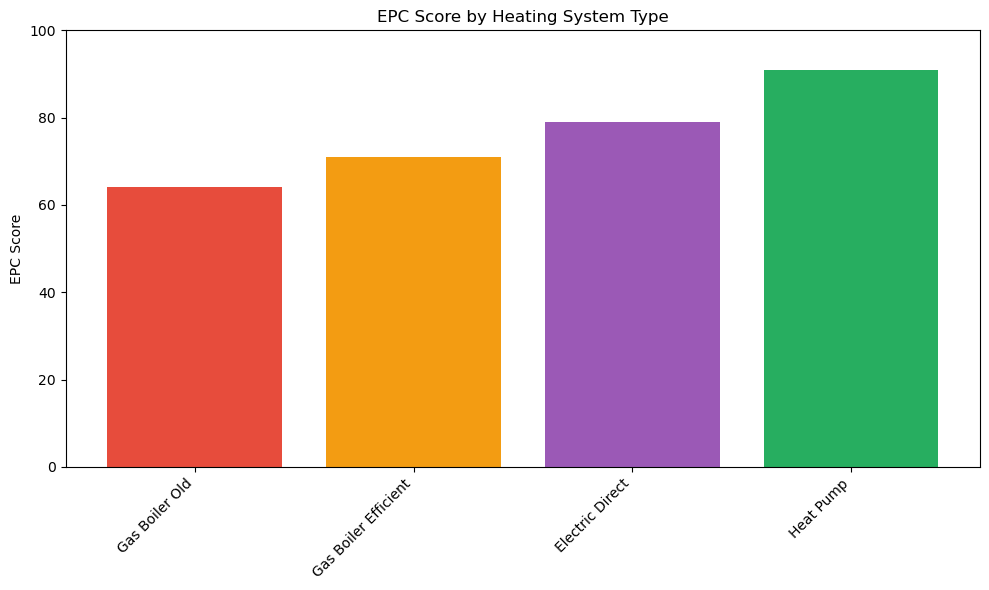

In [8]:
# Analyse impact of different heating systems
base_flat = FlatProperties(
    floor_area_sqm=65,
    position=FlatPosition.MID_FLOOR,
    num_bedrooms=2,
    num_occupants=2,
    year_built=2000,
    wall_type=WallType.CAVITY_INSULATED,
    window_type=WindowType.DOUBLE_GLazed_NEW,
    heating_type=HeatingType.GAS_BOILER_EFFICIENT,
    hot_water_type=HotWaterType.FROM_HEATING,
    has_room_thermostat=True,
    has_trvs=True,
    low_energy_lighting_pct=50,
)

heating_types = [
    HeatingType.GAS_BOILER_OLD,
    HeatingType.GAS_BOILER_EFFICIENT,
    HeatingType.ELECTRIC_DIRECT,
    HeatingType.HEAT_PUMP,
]

print("Heating System Impact on EPC:")
print("-" * 50)
for ht in heating_types:
    test_flat = FlatProperties(
        floor_area_sqm=base_flat.floor_area_sqm,
        position=base_flat.position,
        num_bedrooms=base_flat.num_bedrooms,
        num_occupants=base_flat.num_occupants,
        year_built=base_flat.year_built,
        wall_type=base_flat.wall_type,
        window_type=base_flat.window_type,
        heating_type=ht,
        hot_water_type=base_flat.hot_water_type,
        has_room_thermostat=base_flat.has_room_thermostat,
        has_trvs=base_flat.has_trvs,
        low_energy_lighting_pct=base_flat.low_energy_lighting_pct,
    )
    estimator = EPCEstimator(test_flat)
    result = estimator.calculate_epc()
    print(f"{ht.value:25s}: {result['rating_band']} ({result['rating_score']}) - £{result['estimated_annual_cost_gbp']}/year")

# Create comparison chart
fig, ax = plt.subplots(figsize=(10, 6))
heating_labels = [ht.value.replace('_', ' ').title() for ht in heating_types]
scores = []
for ht in heating_types:
    test_flat = FlatProperties(
        floor_area_sqm=base_flat.floor_area_sqm,
        position=base_flat.position,
        num_bedrooms=base_flat.num_bedrooms,
        num_occupants=base_flat.num_occupants,
        year_built=base_flat.year_built,
        wall_type=base_flat.wall_type,
        window_type=base_flat.window_type,
        heating_type=ht,
        hot_water_type=base_flat.hot_water_type,
        has_room_thermostat=base_flat.has_room_thermostat,
        has_trvs=base_flat.has_trvs,
        low_energy_lighting_pct=base_flat.low_energy_lighting_pct,
    )
    estimator = EPCEstimator(test_flat)
    result = estimator.calculate_epc()
    scores.append(result['rating_score'])

colors = ['#e74c3c', '#f39c12', '#9b59b6', '#27ae60']
bars = ax.bar(heating_labels, scores, color=colors)
ax.set_ylabel('EPC Score')
ax.set_title('EPC Score by Heating System Type')
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Interactive Estimator

Modify the values below to estimate your own flat's EPC rating.

In [9]:
# Configure your flat properties here
my_flat = FlatProperties(
    floor_area_sqm=60,           # Total floor area in square metres
    position=FlatPosition.MID_FLOOR,
    num_bedrooms=2,
    num_occupants=2,
    year_built=1990,
    wall_type=WallType.CAVITY_UNINSULATED,
    window_type=WindowType.DOUBLE_GLazed_OLD,
    heating_type=HeatingType.GAS_BOILER_MODERATE,
    hot_water_type=HotWaterType.FROM_HEATING,
    has_cylinder_thermostat=False,
    has_room_thermostat=True,
    has_trvs=True,
    low_energy_lighting_pct=30,
    has_solar_pv=False,
    solar_pv_kw=0,
    flat_below_insulated=True,
    flat_above_insulated=True,
)

# Calculate and display results
my_estimator = EPCEstimator(my_flat)
my_result = my_estimator.calculate_epc()

print("=" * 50)
print("YOUR FLAT EPC ESTIMATE")
print("=" * 50)
print(f"\nEPC Rating: {my_result['rating_band']} ({my_result['rating_score']}/100)")
print(f"Primary Energy: {my_result['primary_energy_kwh_m2']} kWh/m2/year")
print(f"CO2 Emissions: {my_result['co2_emissions_kg_m2']} kg/m2/year")
print(f"Total CO2: {my_result['total_co2_kg_year']} kg/year")
print(f"Est. Annual Cost: £{my_result['estimated_annual_cost_gbp']}")
print("\nEnergy Breakdown:")
print(f"  Space Heating: {my_result['energy_breakdown']['space_heating_kwh']:,.0f} kWh")
print(f"  Hot Water: {my_result['energy_breakdown']['hot_water_kwh']:,.0f} kWh")
print(f"  Lighting: {my_result['energy_breakdown']['lighting_kwh']:,.0f} kWh")
print(f"  Appliances: {my_result['energy_breakdown']['appliance_kwh']:,.0f} kWh")
print(f"  Cooking: {my_result['energy_breakdown']['cooking_kwh']:,.0f} kWh")
if my_result['energy_breakdown']['solar_generation_kwh'] > 0:
    print(f"  Solar Generation: {my_result['energy_breakdown']['solar_generation_kwh']:,.0f} kWh")
print("=" * 50)

YOUR FLAT EPC ESTIMATE

EPC Rating: D (60/100)
Primary Energy: 218.9 kWh/m2/year
CO2 Emissions: 43.6 kg/m2/year
Total CO2: 2613.0 kg/year
Est. Annual Cost: £1371.0

Energy Breakdown:
  Space Heating: 5,714 kWh
  Hot Water: 3,000 kWh
  Lighting: 465 kWh
  Appliances: 1,100 kWh
  Cooking: 400 kWh


## Notes

This is a simplified estimator for educational purposes. Actual EPC assessments:

- Use the full SAP (Standard Assessment Procedure) methodology
- Require a qualified Domestic Energy Assessor
- Consider many more factors (air tightness, thermal bridging, etc.)
- Produce official certificates valid for 10 years

For an official EPC, visit: https://www.gov.uk/get-new-energy-certificate